# Patch Dataset Viewer

Total image counts per repo, and 5 random patches shown across all 4 image types.

In [45]:
import os
import random
from PIL import Image
import matplotlib.pyplot as plt

SAT_OUT    = "/Volumes/Spleen/CABIN/datasets/patches/satellite_imagery"
DEM_OUT    = "/Volumes/Spleen/CABIN/datasets/patches/elevation"
CANOPY_OUT = "/Volumes/Spleen/CABIN/datasets/patches/crown_closure"
MASK_OUT   = "/Volumes/Spleen/CABIN/datasets/patches/crown_closure_mask"

REPOS = {
    "Satellite": SAT_OUT,
    "Elevation": DEM_OUT,
    "Crown Closure Mask": MASK_OUT,
    "Crown Closure": CANOPY_OUT,
}

In [8]:
counts = {
    name: len([f for f in os.listdir(path) if f.startswith("patch_") and f.endswith(".png")])
    for name, path in REPOS.items()
}

for name, count in counts.items():
    print(f"{name:20s}: {count} images")

print(f"\nTotal images across all 4 repos: {sum(counts.values())}")

Satellite           : 5616 images
Elevation           : 5616 images
Crown Closure Mask  : 5616 images
Crown Closure       : 5616 images

Total images across all 4 repos: 22464


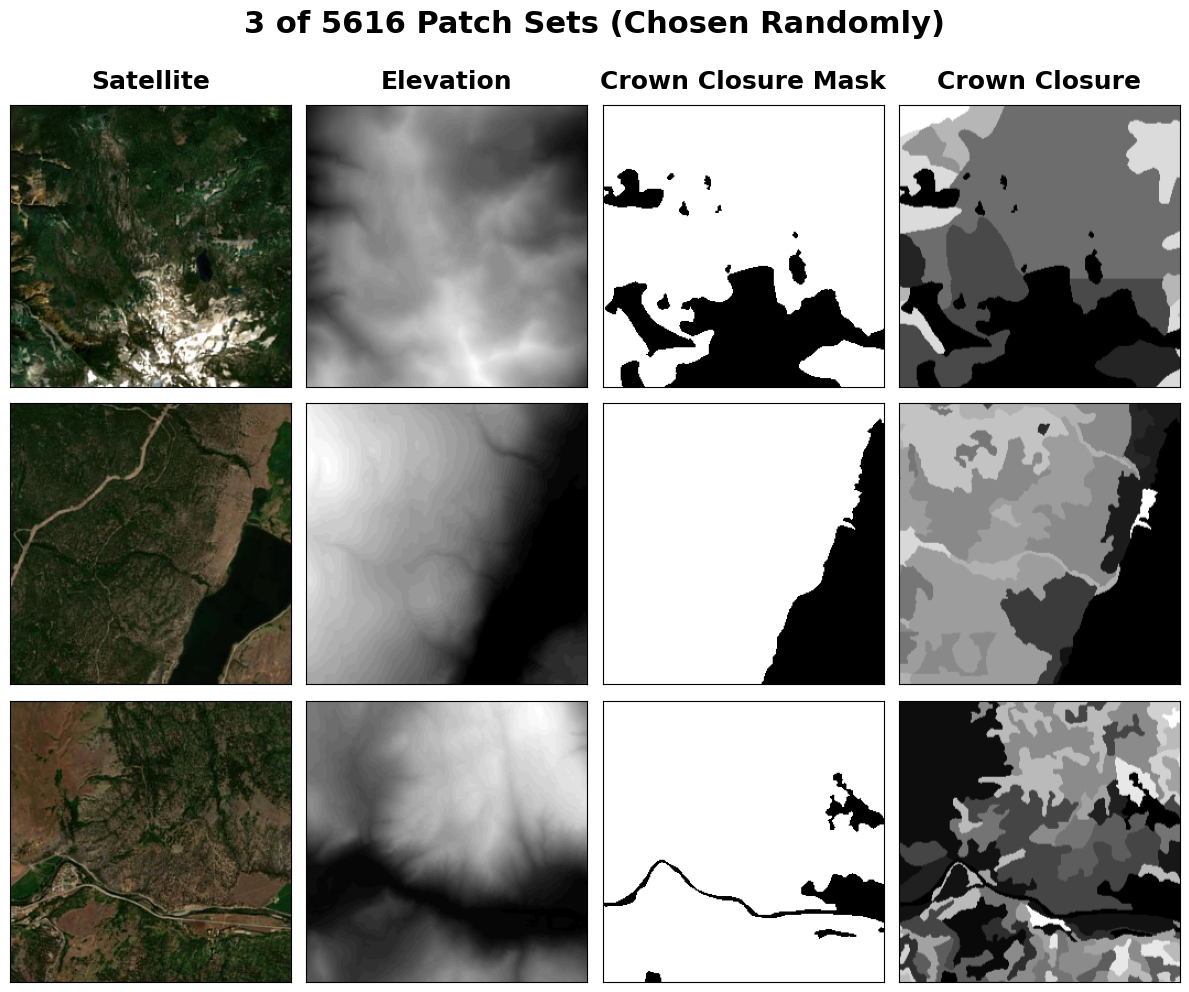

In [44]:
sat_files = sorted(f for f in os.listdir(SAT_OUT) if f.startswith("patch_") and f.endswith(".png"))
sample = random.sample(sat_files, 3)

fig, axes = plt.subplots(3, 4, figsize=(12, 10))

for row, filename in enumerate(sample):
    for col, (name, path) in enumerate(REPOS.items()):
        img_path = os.path.join(path, filename)
        ax = axes[row, col]
        if os.path.exists(img_path):
            ax.imshow(Image.open(img_path), cmap="gray")
        else:
            ax.text(0.5, 0.5, "missing", ha="center", va="center", transform=ax.transAxes, fontsize=14, fontweight="bold")
        ax.set_xticks([])
        ax.set_yticks([])
        if row == 0:
            ax.set_title(name, fontsize=18, fontweight="bold", pad=12)

fig.suptitle("3 of 5616 Patch Sets (Chosen Randomly)", fontsize=22, fontweight="bold", y=1)

plt.tight_layout()
os.makedirs("../plots", exist_ok=True)
# plt.savefig("../plots/random_patch_sets.png", dpi=300, bbox_inches="tight")
plt.show()

In [52]:
import pandas as pd

data = pd.read_csv("../datasets/patch_point_samples.csv")

In [62]:
round(data['mask'].value_counts()/len(data), 3)

mask
1    0.68
0    0.32
Name: count, dtype: float64

In [ ]:
edit my CABIN_trainer, add to it to have a section where it trains a simple linear
  regression model. It should be getting loss from training and test sets so they can be
  plotted on each epoch. I want to know RMSE mainly since it has units I can understand
  (average error in predicted closure). I also want the p-values, ceofs, and R2 and adj R2.
  First make it basic, and limit yourself to RGB and elevation to predict closure, then if
  can think of a way to use mask to predict better do that, like maybe predict mask first
  then using an ignore mask on the 0s for the loss function of the next model, or something
  like that, if you do this, I want all the values I mentioned for both models. Do stratified
  sampling such that for every block of 4 patches (geospatially a square) and.